# Modelo de classificação de Hipertireoidismo

## 1. Importando bibliotecas, base da dados e verificando colunas

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import classification_report  
import matplotlib.pyplot as plt  
from sklearn.preprocessing import LabelEncoder  
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
import xgboost as xgb
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pd.set_option('display.max_columns', None) # Mostra todas as colunas do dataframe

In [2]:
df = pd.read_csv('Base_M43_Pratique_Hypothyroid.csv', sep=',')
df#.head()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,query hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH measured,TSH,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1.3,t,2.5,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,4.1,t,2,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.98,f,?,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.16,t,1.9,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.72,t,1.2,t,61,t,0.87,t,70,f,?,SVI,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3767,30,F,f,f,f,f,f,f,f,f,f,f,f,t,f,f,f,?,f,?,f,?,f,?,f,?,f,?,other,P
3768,68,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1,t,2.1,t,124,t,1.08,t,114,f,?,SVI,P
3769,74,F,f,f,f,f,f,f,f,f,t,f,f,f,f,f,t,5.1,t,1.8,t,112,t,1.07,t,105,f,?,other,P
3770,72,M,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.7,t,2,t,82,t,0.94,t,87,f,?,SVI,P


df.head()

In [3]:
df.describe()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,query hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH measured,TSH,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
count,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772
unique,94,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,288,2,70,2,242,2,147,2,235,1,1,5,2
top,59,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,?,t,?,t,?,t,?,t,?,f,?,other,P
freq,95,2480,3308,3722,3729,3625,3719,3719,3713,3538,3535,3754,3738,3676,3771,3588,3403,369,3003,769,3541,231,3385,387,3387,385,3772,3772,2201,3481


Com uma análise inicial, é possível observar que diversas colunas contêm valores ausentes, representados pelo caractere `?`. Além disso, as colunas `TBG measured` e `TBG` apresentam o mesmo valor em todas as linhas, ou seja, não possuem variabilidade e, consequentemente, não agregam informação relevante para a base de dados.

## 2. Limpando o dataframe

Aqui iremos passar coluna por coluna para e tratar o que for preciso

### Coluna `age`

In [4]:
df['age'].value_counts()

age
59     95
60     91
70     90
55     81
73     81
       ..
4       1
5       1
455     1
?       1
6       1
Name: count, Length: 94, dtype: int64

In [5]:
# Transforma o ? em nan e depois transforma a coluna em numerica
df['age'] = df['age'].replace('?', np.nan).astype(float)

In [6]:
# Nota-se que há um valor muito acima de 100 anos, o que é estranho
df['age'].nlargest(4)

1364    455.0
1129     94.0
2673     94.0
2418     93.0
Name: age, dtype: float64

In [7]:
# Substitui os valores incongruentes pela mediana
df['age'] = df['age'].replace(455.0, df['age'].median()).fillna(df['age'].median())

### Coluna `sex`

In [8]:
df['sex'].value_counts()

sex
F    2480
M    1142
?     150
Name: count, dtype: int64

Foram identificados 150 valores desconhecidos. Vamos analisar as linhas em que eles aparecem para definir a estratégia mais adequada para tratá-los.

In [9]:
df[df['sex']=="?"]

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,query hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH measured,TSH,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
16,42.0,?,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1.2,t,1.8,t,70,t,0.86,t,81,f,?,other,P
47,21.0,?,f,f,f,f,f,f,f,f,f,f,f,f,f,f,f,?,t,1.8,t,163,t,1.05,t,155,f,?,other,P
61,42.0,?,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.02,t,2.6,t,138,t,1.58,t,88,f,?,STMW,P
64,38.0,?,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,2.9,t,1.8,t,93,t,0.95,t,98,f,?,other,P
69,45.0,?,t,f,f,f,f,f,f,f,f,f,f,f,f,f,t,9,t,2.8,t,237,t,1.17,t,203,f,?,STMW,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3562,38.0,?,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1.2,t,2,t,101,t,1.01,t,100,f,?,SVHC,P
3566,47.0,?,f,f,f,t,f,f,f,f,f,f,f,f,f,f,t,0.02,t,1.9,t,111,t,0.93,t,119,f,?,other,P
3574,22.0,?,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,3.1,t,2.7,t,136,t,1.27,t,107,f,?,other,P
3630,40.0,?,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,2.1,t,0.6,t,79,t,0.91,t,87,f,?,other,P


In [10]:
df[df['sex']=="?"]['pregnant'].value_counts()

pregnant
f    148
t      2
Name: count, dtype: int64

In [11]:
# Como a classe majoritária é de mulheres, vamos assumir que os 150 casos sem informação são mulheres também
df['sex'] = df['sex'].replace('?', 'F')

In [12]:
# Agora passamos a coluna para numérica
df['sex'] = df['sex'].map({'F': 0, 'M': 1})

In [13]:
df['sex'].value_counts()

sex
0    2630
1    1142
Name: count, dtype: int64

### Coluna `on thyroxine` até `TSH measured`, junto com `T3 measured`, `TT4 measured`, `T4U measured`, `FTI measured`

Essas colunas são binárias, então basta transformá-las em numérica

In [14]:
colunas = ['on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment',
           'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured',
           'TT4 measured', 'T4U measured', 'FTI measured']

for col in colunas:
    df[col] = df[col].map({'f': 0, 't': 1})

### Coluna `TSH`

In [15]:
df['TSH'].value_counts()

TSH
?       369
0.2     116
1.3     105
1.1      97
1.4      91
       ... 
165       1
80        1
9.5       1
30.5      1
0.18      1
Name: count, Length: 288, dtype: int64

In [16]:
# Transforma o ? em nan e depois transforma a coluna em numerica
df['TSH'] = df['TSH'].replace('?', np.nan).astype(float)

In [17]:
df['TSH'].describe()

count    3403.000000
mean        5.086766
std        24.521470
min         0.005000
25%         0.500000
50%         1.400000
75%         2.700000
max       530.000000
Name: TSH, dtype: float64

Ao analisar os resultados acima, observa-se a presença de valores substancialmente superiores à mediana. Embora esses pontos pudessem ser interpretados como outliers, é bem documentado na literatura médica que o TSH pode atingir faixas centenárias em quadros severos de hipotireoidismo.

Como o objetivo do projeto é justamente identificar indivíduos com essa condição, a remoção desses dados eliminaria padrões cruciais para o modelo. Portanto, os outliers serão mantidos na base de dados. Quanto aos valores ausentes, eles serão imputados utilizando a mediana.

In [18]:
# Substitui os nan pela mediana
df['TSH'] = df['TSH'].fillna(df['TSH'].median())

### Coluna `T3`

In [19]:
df['T3'].value_counts()

T3
?       769
2       238
1.8     207
2.2     201
1.9     189
       ... 
8.5       1
1.44      1
7.6       1
5.7       1
6.6       1
Name: count, Length: 70, dtype: int64

In [20]:
# Transforma o ? em nan e depois transforma a coluna em numerica
df['T3'] = df['T3'].replace('?', np.nan).astype(float)

In [21]:
df['T3'].describe()

count    3003.000000
mean        2.013500
std         0.827434
min         0.050000
25%         1.600000
50%         2.000000
75%         2.400000
max        10.600000
Name: T3, dtype: float64

Os valores de T3 apresentados não exibem anomalias ou incoerências significativas. Portanto, aplicaremos a imputação dos valores ausentes utilizando a mediana da variável.

In [22]:
# Substitui os nan pela mediana
df['T3'] = df['T3'].fillna(df['T3'].median())

### Coluna `TT4`

In [23]:
df['TT4'].value_counts()

TT4
?      231
101     71
93      67
103     63
98      63
      ... 
30       1
2.9      1
55       1
216      1
258      1
Name: count, Length: 242, dtype: int64

In [24]:
# Transforma o ? em nan e depois transforma a coluna em numerica
df['TT4'] = df['TT4'].replace('?', np.nan).astype(float)

In [25]:
df['TT4'].nlargest(10)

743     430.0
1415    430.0
3258    372.0
2671    301.0
2366    289.0
3095    273.0
604     272.0
2617    263.0
2824    261.0
3756    258.0
Name: TT4, dtype: float64

In [26]:
df['TT4'].describe()

count    3541.000000
mean      108.319345
std        35.604248
min         2.000000
25%        88.000000
50%       103.000000
75%       124.000000
max       430.000000
Name: TT4, dtype: float64

Assim como na variável `TSH`, observam-se valores significativamente afastados da mediana. A remoção desses pontos não será realizada, pois eles carregam informações altamente relevantes para a identificação de anomalias da tireoide.

Portanto, os outliers serão preservados e aplicaremos a imputação pela mediana apenas para o tratamento dos valores ausentes.

In [27]:
# Substitui os nan pela mediana
df['TT4'] = df['TT4'].fillna(df['TT4'].median())

### Coluna `T4U`

In [28]:
df['T4U'].value_counts()

T4U
?       387
0.99     95
0.9      93
1.01     91
1        90
       ... 
1.54      1
0.47      1
0.36      1
2.01      1
0.25      1
Name: count, Length: 147, dtype: int64

In [29]:
# Transforma o ? em nan e depois transforma a coluna em numerica
df['T4U'] = df['T4U'].replace('?', np.nan).astype(float)

In [30]:
df['T4U'].nlargest(10)

2824    2.32
1961    2.12
740     2.03
3690    2.01
530     1.97
1926    1.94
300     1.93
2170    1.88
2737    1.88
995     1.84
Name: T4U, dtype: float64

In [31]:
df['T4U'].describe()

count    3385.000000
mean        0.995000
std         0.195457
min         0.250000
25%         0.880000
50%         0.980000
75%         1.080000
max         2.320000
Name: T4U, dtype: float64

Assim como na variável anterior, observam-se valores significativamente afastados da mediana. A remoção desses pontos não será realizada, pois eles carregam informações altamente relevantes para a identificação de anomalias da tireoide.

Portanto, os outliers serão preservados e aplicaremos a imputação pela mediana apenas para o tratamento dos valores ausentes.

In [32]:
# Substitui os nan pela mediana
df['T4U'] = df['T4U'].fillna(df['T4U'].median())

### Coluna `FTI`

In [33]:
df['FTI'].value_counts()

FTI
?      385
100     73
93      70
114     65
107     64
      ... 
9.1      1
27       1
15       1
35       1
227      1
Name: count, Length: 235, dtype: int64

In [34]:
# Transforma o ? em nan e depois transforma a coluna em numerica
df['FTI'] = df['FTI'].replace('?', np.nan).astype(float)

In [35]:
df['FTI'].nlargest(10)

743     395.0
1415    395.0
456     362.0
1671    349.0
542     312.0
3258    291.0
2995    283.0
604     281.0
3555    280.0
151     274.0
Name: FTI, dtype: float64

In [36]:
df['FTI'].describe()

count    3387.000000
mean      110.469649
std        33.089698
min         2.000000
25%        93.000000
50%       107.000000
75%       124.000000
max       395.000000
Name: FTI, dtype: float64

Assim como na variável anterior, observam-se valores significativamente afastados da mediana. A remoção desses pontos não será realizada, pois eles carregam informações altamente relevantes para a identificação de anomalias da tireoide.

Portanto, os outliers serão preservados e aplicaremos a imputação pela mediana apenas para o tratamento dos valores ausentes.

In [37]:
# Substitui os nan pela mediana
df['FTI'] = df['FTI'].fillna(df['FTI'].median())

### Coluna `TBG measured` e `TBG`

Conforme mencionado anteriormente, essas colunas não apresentam variabilidade (variância zero) e, portanto, serão removidas do dataset para evitar a presença de features não informativas.

In [38]:
df = df.drop(columns=['TBG measured', 'TBG'])

In [39]:
print(df.columns.tolist())

['age', 'sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH', 'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U', 'FTI measured', 'FTI', 'referral source', 'binaryClass']


### Coluna `referral source`

In [40]:
df['referral source'].value_counts()

referral source
other    2201
SVI      1034
SVHC      386
STMW      112
SVHD       39
Name: count, dtype: int64

A coluna `referral source` não apresenta inconsistências nem valores ausentes. Portanto, haverá apenas a alteração de passar essa coluna categórica para numérica.

In [41]:
# Utiliza o get_dummies para gerar colunas referentes a cada classe
df = pd.get_dummies(df, columns=['referral source'], dtype=int)

# Move a coluna 'binaryClass' para o final do dataframe
coluna_alvo = df.pop('binaryClass')
df['binaryClass'] = coluna_alvo

### Coluna `binaryClass`

In [42]:
df['binaryClass'].value_counts()

binaryClass
P    3481
N     291
Name: count, dtype: int64

A coluna `binaryClass` (nossa coluna alvo) não apresenta inconsistências nem valores ausentes. Portanto, apenas passaremos os valores P (com hipotiroidismo) para 1 e N (sem hipotiroidismo) para 0

In [43]:
# Passando a coluna para valores numéricos
df['binaryClass'] = df['binaryClass'].map({'N': 0, 'P': 1})

## 3. Análise Univariada

Nesta etapa, algumas variáveis serão analisadas individualmente, com o objetivo de compreender sua distribuição, identificar padrões e extrair insights relevantes sobre o conjunto de dados.

In [44]:
df.shape

(3772, 32)

### Idade dos pacientes

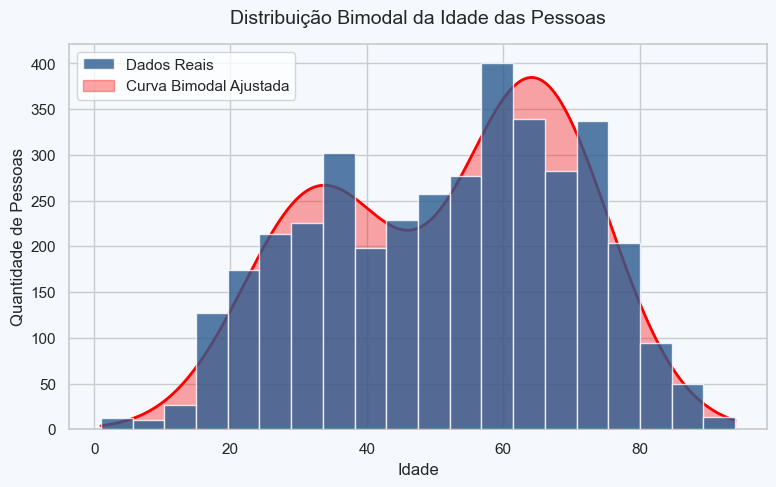

In [45]:
# 1. Preparar os dados
ages = df['age'].values.reshape(-1, 1)
n_samples = len(ages)  # Total de observações
n_bins = 20            # Número de barras do histograma

# 2. Ajustar a Mistura de Normais (2 componentes)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(ages)

# 3. Gerar a curva de densidade original (probabilidade)
x = np.linspace(ages.min(), ages.max(), 300).reshape(-1, 1)
y_prob = np.exp(gmm.score_samples(x))

# 4. Calcular a largura do bin para converter probabilidade -> quantidade
bin_width = (ages.max() - ages.min()) / n_bins

# Multiplicamos a probabilidade pelo total de dados e pela largura do bin
y_count = y_prob * n_samples * bin_width

# 5. Plotar os dados
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(9, 5))
fig.patch.set_facecolor('#F5F8FC')

ax = plt.gca()
ax.set_facecolor('#F5F8FC')

# Histograma em QUANTIDADE (sem o parâmetro density=True)
plt.hist(ages, bins=n_bins, color='#2b5c8f', edgecolor='white', alpha=0.8, zorder=3, label='Dados Reais')

# Curva bimodal em QUANTIDADE no fundo
plt.fill_between(x.ravel(), y_count, color='red', alpha=0.35, label='Curva Bimodal Ajustada', zorder=1)
plt.plot(x.ravel(), y_count, color='red', linewidth=2, zorder=2)

# Rótulos ajustados para Frequência / Quantidade
plt.title('Distribuição Bimodal da Idade das Pessoas', fontsize=14, pad=15)
plt.xlabel('Idade')
plt.ylabel('Quantidade de Pessoas')
plt.legend()

plt.show()

O gráfico demonstra que a distribuição de idades se ajusta significativamente melhor a um modelo bimodal (mistura de duas distribuições normais) do que a uma distribuição unimodal padrão. Identificam-se dois picos claros de concentração: o primeiro entre 25 e 40 anos, e um segundo, mais expressivo, entre 50 e 75 anos.

Essa assimetria evidencia um predomínio relevante de indivíduos acima dos 50 anos, uma faixa etária associada a um maior risco epidemiológico e maior propensão ao desenvolvimento de patologias em comparação com o grupo de adultos jovens.

### Gênero dos pacientes

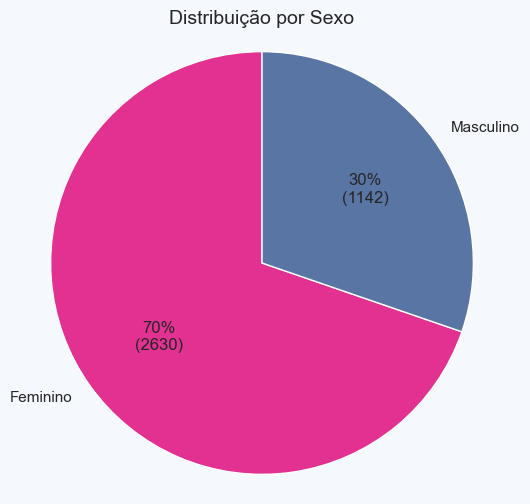

In [46]:
contagem = df['sex'].value_counts()

labels = {
    1: 'Masculino',
    0: 'Feminino'
}

def mostrar_valor_e_percentual(pct):
    total = contagem.sum()
    valor = int(round(pct * total / 100))
    return f'{pct:.0f}%\n({valor})'

# Define as cores de acordo com o sexo
cores = [
    '#5975A4' if sexo == 1 else '#E23191'
    for sexo in contagem.index
]

fig = plt.figure(figsize=(6, 6))
fig.patch.set_facecolor('#F5F8FC')

# Fundo da área do gráfico
ax = plt.gca()
ax.set_facecolor('#F5F8FC')
plt.pie(contagem, labels=[labels.get(x, x) for x in contagem.index], colors=cores, autopct=mostrar_valor_e_percentual, startangle=90)

plt.title('Distribuição por Sexo', fontsize=14)
plt.axis('equal')
plt.show()

No conjunto de dados, observa-se uma predominância de mulheres em relação aos homens. Elas representam aproximadamente **70%** dos indivíduos, enquanto os homens correspondem a cerca de **30%**, ou seja, há mais que o dobro de mulheres em comparação aos homens.

### Mulheres grávidas

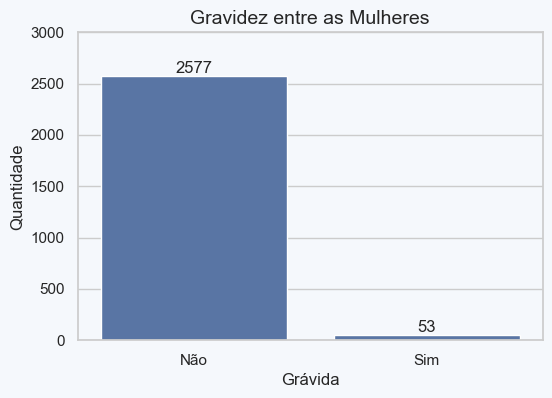

In [47]:
# Filtra apenas as mulheres
df_mulheres = df[df['sex'] == 0].copy()
df_mulheres['pregnant'] = df_mulheres['pregnant'].map({0: 'Não', 1: 'Sim'})

fig = plt.figure(figsize=(6, 4))
fig.patch.set_facecolor('#F5F8FC')

ax = sns.countplot(data=df_mulheres, x='pregnant')

# Fundo da área do gráfico
ax.set_facecolor('#F5F8FC')

# Adiciona a quantidade em cima de cada barra
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

# Define titulo e legendas
plt.title('Gravidez entre as Mulheres', fontsize=14)
plt.xlabel('Grávida')
plt.ylabel('Quantidade')

# Define o eixo Y
plt.ylim(0, 3000)

plt.show()

Observa-se que a grande maioria das mulheres do conjunto de dados não está grávida. Das 2.630 mulheres, 2.577 (98,0%) não estão grávidas, enquanto apenas 53 (2,0%) estão. Isso evidencia um forte desbalanceamento entre as classes, com predominância de mulheres não grávidas na amostra.

### Pacientes que fizeram cirurgia na tireoide

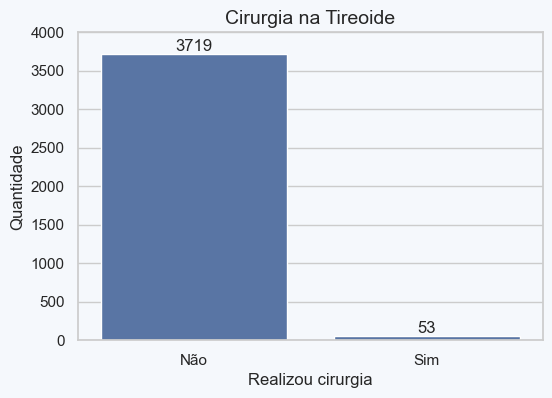

In [48]:
fig = plt.figure(figsize=(6, 4))
fig.patch.set_facecolor('#F5F8FC')

ax = sns.countplot(data=df, x='thyroid surgery')

# Altera os rótulos do eixo X
ax.set(
    xticks=[0, 1],
    xticklabels=['Não', 'Sim']
)

# Fundo da área do gráfico
ax.set_facecolor('#F5F8FC')

# Adiciona a quantidade em cima de cada barra
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Cirurgia na Tireoide', fontsize=14)
plt.xlabel('Realizou cirurgia')
plt.ylabel('Quantidade')

# Define o eixo Y
plt.ylim(0, 4000)

plt.show()

Observa-se que a grande maioria dos indivíduos do conjunto de dados nunca realizou cirurgia na tireoide. Dos 3.772 registros, 3.719 (98,6%) correspondem a pessoas que não passaram por esse procedimento, enquanto apenas 53 (1,4%) realizaram cirurgia. Isso evidencia um forte desbalanceamento entre as categorias, indicando que a ocorrência de cirurgia na tireoide é rara na amostra.

## 4. Análise Bivariada

Nesta seção, serão analisadas as relações entre as variáveis do conjunto de dados, buscando extrair insights relevantes.

### Relação entre Gênero e Indivíduos doentes

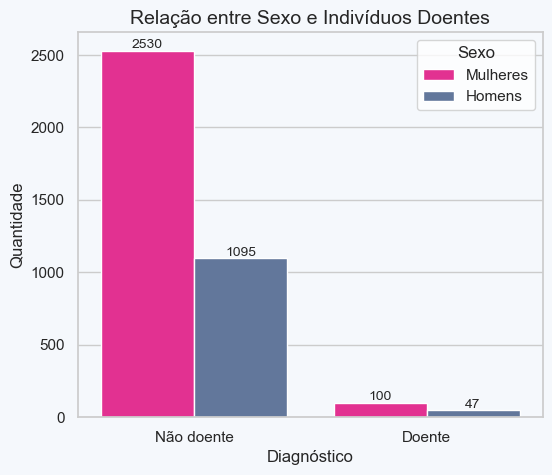

In [49]:
fig = plt.figure(figsize=(6, 5))
fig.patch.set_facecolor('#F5F8FC')

ax = sns.countplot(
    data=df,
    x='sick',
    hue='sex',
    palette={1: '#5975A4', 0: 'deeppink'}
)

# Renomeia os eixos
ax.set(
    xticks=[0, 1],
    xticklabels=['Não doente', 'Doente']
)

# Fundo da área do gráfico
ax.set_facecolor('#F5F8FC')

# Renomeia a legenda
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Mulheres', 'Homens'], title='Sexo')

# Adiciona os valores sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f'{int(altura)}',
            (p.get_x() + p.get_width()/2, altura),
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title('Relação entre Sexo e Indivíduos Doentes', fontsize=14)
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade')

plt.show()

Embora o número absoluto de mulheres doentes seja maior que o de homens, isso ocorre porque o conjunto de dados possui uma quantidade significativamente maior de mulheres. Ao analisar as proporções dentro de cada sexo, observa-se que a prevalência da doença é bastante semelhante: aproximadamente 3,8% entre as mulheres e 4,1% entre os homens. Portanto, com base nesse gráfico, não há evidências de uma diferença expressiva na ocorrência da doença entre homens e mulheres. A principal diferença observada decorre do desbalanceamento da amostra em relação ao sexo.

### Relação entre Idade e Presença de Tumor

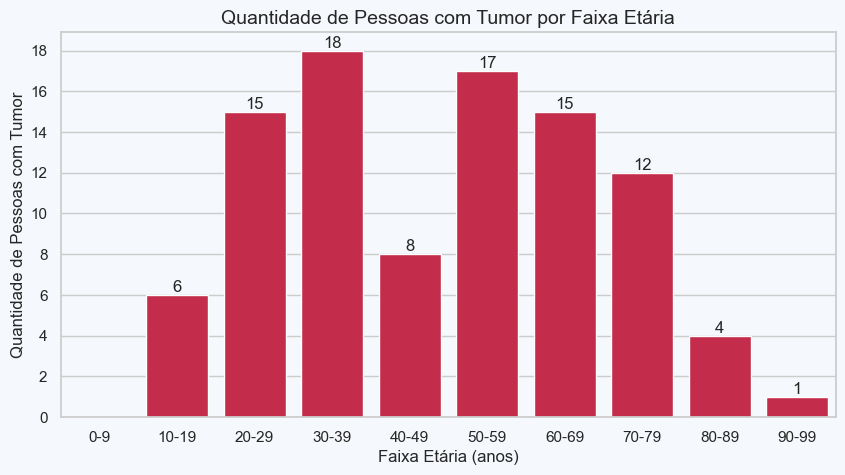

In [50]:
from matplotlib.ticker import MaxNLocator

# Cria faixas etárias de 10 em 10 anos
bins = range(0, 101, 10)  # 0-10, 10-20, ..., 90-100
labels = [f'{i}-{i+9}' for i in bins[:-1]]

# Cria a coluna faixa_etaria
df['faixa_etaria'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=False
)

# Filtra apenas quem possui tumor
df_tumor = df[df['tumor'] == 1]

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor('#F5F8FC')

ax = sns.countplot(
    data=df_tumor,
    x='faixa_etaria',
    color='crimson'
)

# Fundo da área do gráfico
ax.set_facecolor('#F5F8FC')

# Força o eixo Y a usar apenas inteiros
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Adiciona os valores sobre as barras
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f'{int(altura)}',
            (p.get_x() + p.get_width()/2, altura),
            ha='center',
            va='bottom'
        )

plt.title('Quantidade de Pessoas com Tumor por Faixa Etária', fontsize=14)
plt.xlabel('Faixa Etária (anos)')
plt.ylabel('Quantidade de Pessoas com Tumor')

plt.show()

# Deleta a coluna faixa_etaria
df = df.drop(columns='faixa_etaria')

O gráfico apresenta uma distribuição bimodal da quantidade de pacientes com tumor por faixa etária, com dois picos principais: um entre 30 e 39 anos e outro entre 50 e 59 anos. Esse comportamento é bastante semelhante à distribuição da idade dos pacientes do conjunto de dados, indicando que a ocorrência de tumores acompanha a distribuição etária da amostra. Assim, não há evidências de que uma faixa etária específica apresente uma concentração desproporcional de casos; em vez disso, os tumores estão distribuídos de forma aproximadamente proporcional ao número de pacientes em cada faixa de idade.

### Relação entre o uso de remédios antitireoidiano e hipertiroidismo

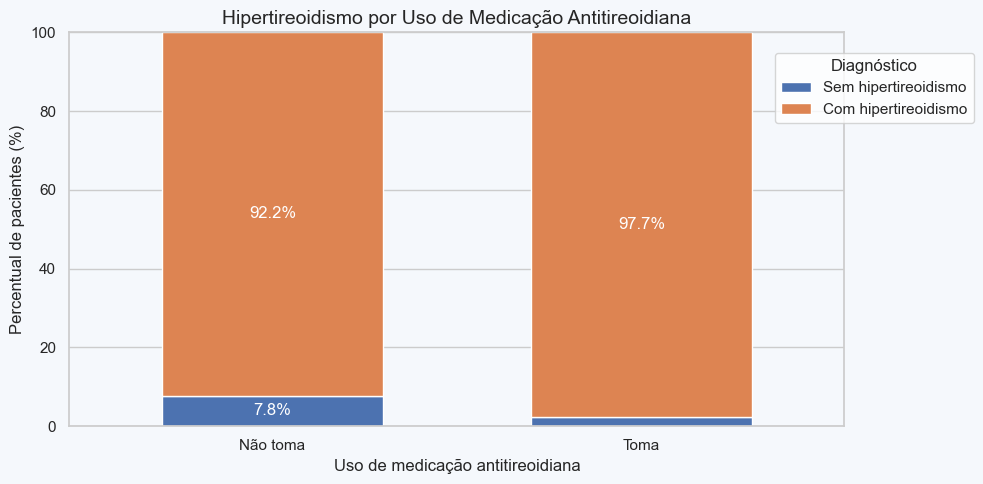

In [51]:
# Tabela de contingência em porcentagem
dados = pd.crosstab(
    df['on antithyroid medication'],
    df['binaryClass'],
    normalize='index'
) * 100

# Renomeando para ficar mais legível
dados.index = ['Não toma', 'Toma']
dados.columns = ['Sem hipertireoidismo', 'Com hipertireoidismo']

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

fig.patch.set_facecolor('#F5F8FC')
ax.set_facecolor('#F5F8FC')

dados.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.6
)

plt.title('Hipertireoidismo por Uso de Medicação Antitireoidiana', fontsize=14)
plt.xlabel('Uso de medicação antitireoidiana')
plt.ylabel('Percentual de pacientes (%)')
ax.legend(title='Diagnóstico', loc='lower left', bbox_to_anchor=(0.9, 0.75), frameon=True)

# Coloca os percentuais dentro das barras
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%'
        if v.get_height() > 3 else ''
        for v in c
    ]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontsize=12)

plt.xticks(rotation=0)

# Limite do eixo Y
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

O gráfico evidencia uma forte relação entre o uso de medicação antitireoidiana e o diagnóstico de hipertireoidismo. Entre os pacientes que fazem uso desse tipo de medicamento, 97,7% possuem diagnóstico positivo para hipertireoidismo, enquanto apenas 2,3% não apresentam a doença. Esses poucos casos podem ser explicados por diferentes fatores, como pacientes em remissão após o tratamento, registros inconsistentes na base de dados ou outras condições clínicas que justifiquem o uso da medicação.

O resultado mais interessante, entretanto, está no grupo de pacientes que não utilizam medicação antitireoidiana. Dentre eles, 92,2% apresentam diagnóstico de hipertireoidismo. Esse achado sugere que uma parcela significativa dos indivíduos diagnosticados não está em tratamento medicamentoso. As possíveis explicações incluem casos recém-diagnosticados, pacientes que ainda não iniciaram o tratamento, indivíduos que interromperam ou recusaram a medicação, ou limitações e inconsistências presentes na própria base de dados. Portanto, embora exista uma forte associação entre o uso da medicação e a presença da doença, o gráfico também evidencia que o diagnóstico não implica necessariamente que o paciente esteja em tratamento.

### Matriz de Correlação

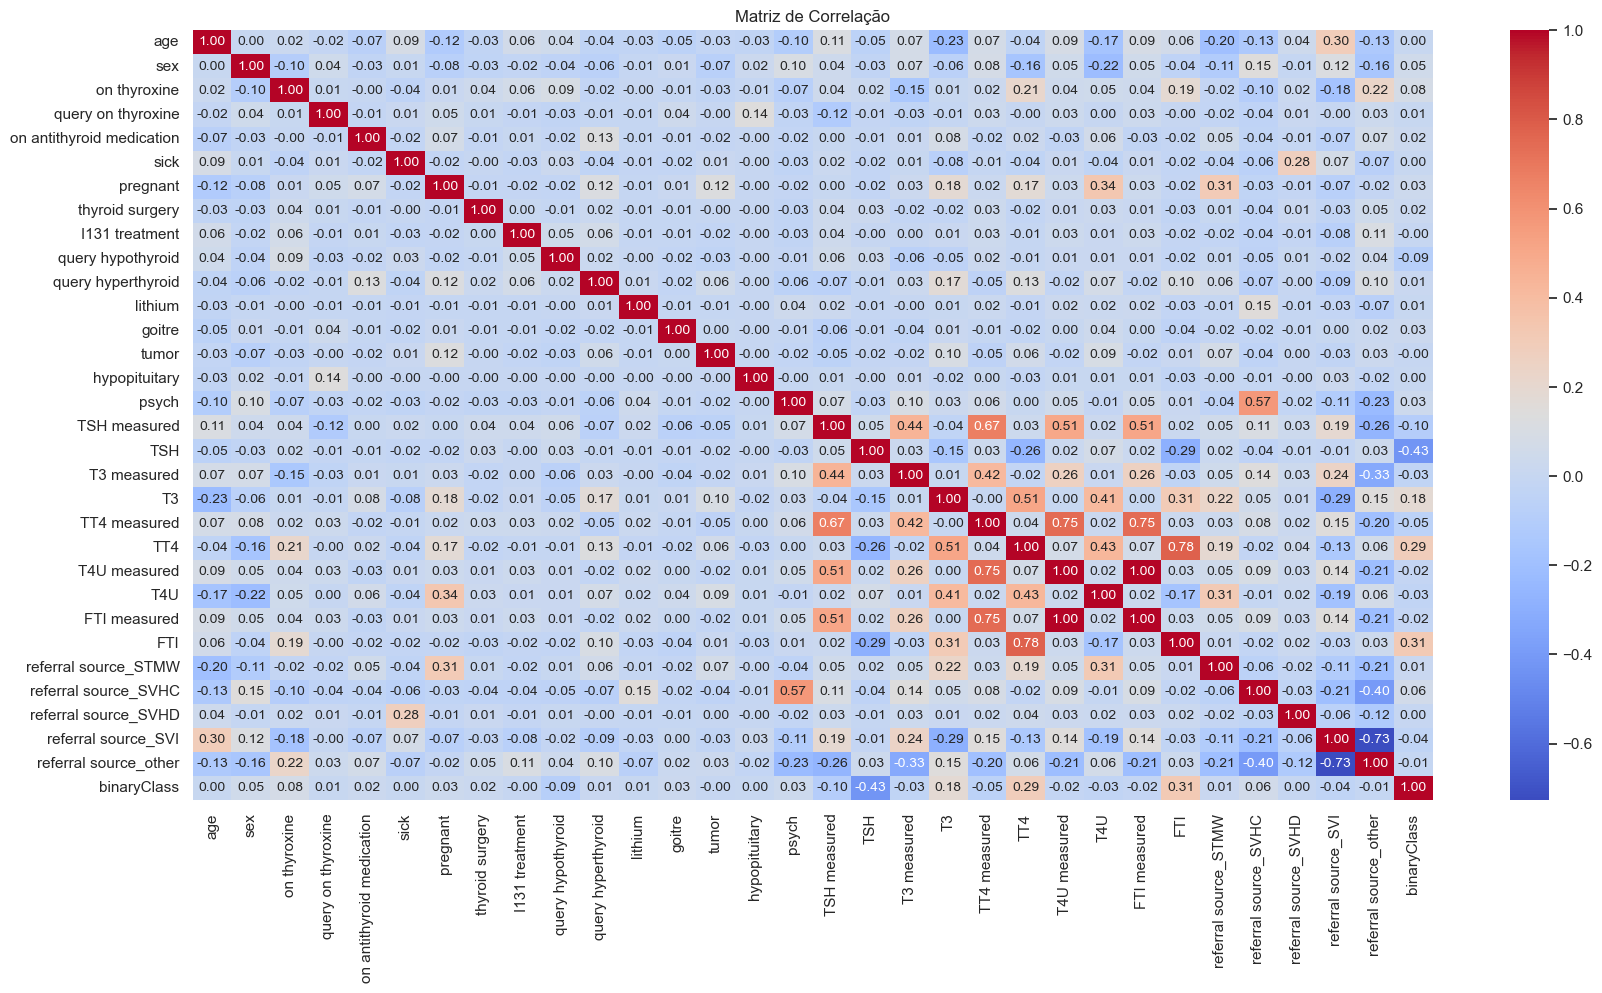

In [52]:
# Matriz de correlação
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

In [53]:
# Mostra as 6 colunas que possuem a maior correlação com a coluna 'binaryClass' (removendo a própria 'binaryClass' cuja correlação é 1)
correlation_matrix['binaryClass'].drop('binaryClass').sort_values(key=abs, ascending=False).head(6)

TSH                 -0.427963
FTI                  0.313098
TT4                  0.289514
T3                   0.177436
TSH measured        -0.095209
query hypothyroid   -0.086282
Name: binaryClass, dtype: float64

A variável alvo, `binaryClass`, apresenta as maiores correlações com quatro outras variáveis: `TSH`, `FTI`, `TT4` e `T3`.

* **`TSH`** apresenta uma **correlação inversa** de **-0,43**, indicando que, à medida que os valores de `TSH` aumentam, há uma tendência de redução nos valores de `binaryClass`.
* **`FTI`** apresenta uma **correlação direta** de **0,31**, indicando uma relação positiva moderada entre as duas variáveis.
* **`TT4`** apresenta uma **correlação direta** de **0,28**, indicando uma relação positiva, porém de menor intensidade.
* **`T3`** apresenta uma **correlação direta** de **0,18**, caracterizando uma relação positiva mais fraca.

De modo geral, `TSH` é a variável que apresenta a maior correlação, em valor absoluto, com a variável alvo, seguida por `FTI`, `TT4` e `T3`.


## 5. Padronização e Balanceamento dos dados

### 1) Separação em treino e teste

In [54]:
# Separação em X e Y
X = df.drop(columns='binaryClass')
y = df['binaryClass']

In [55]:
# Separação em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2) Padronização

In [56]:
# Instancia o StandartScaler
scaler = StandardScaler()

# Padroniza os dados
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

É importante observar que a padronização é aplicada apenas às variáveis preditoras (features), e não à variável alvo. Esse procedimento é realizado tanto nos dados de treinamento quanto nos dados de teste, utilizando os parâmetros de padronização calculados exclusivamente a partir dos dados de treinamento.

### 3) Balanceamento

In [57]:
# Instancia o SMOTE
smote = SMOTE(random_state=42)

# Balancea os dados
X_train_scaled_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [58]:
print(y_train.value_counts())
print(y_train_balanced.value_counts())

binaryClass
1    2784
0     233
Name: count, dtype: int64
binaryClass
1    2784
0    2784
Name: count, dtype: int64


Diferentemente da padronização, o balanceamento é realizado **exclusivamente nos dados de treinamento**, abrangendo tanto as variáveis preditoras (features) quanto a variável alvo. Os dados de teste não são balanceados, pois devem preservar a distribuição original das classes para permitir uma avaliação mais fiel do desempenho do modelo.

## 6. Implementando o modelo

Nesta seção, serão implementados e avaliados dois modelos de aprendizado de máquina: SVM e XGBoost. O objetivo é comparar o desempenho dos modelos na classificação da variável alvo `binaryClass`.

### 1) SVM sem otimização de hiperparâmetros

In [59]:
# Instancia o modelo SVM
svm = SVC(random_state=42)

# Treina o modelo
svm.fit(X_train_scaled_balanced, y_train_balanced)

SVC(random_state=42)

In [60]:
# Realiza as previsões
y_pred_svm = svm.predict(X_test_scaled)

In [61]:
# Avaliando o modelo
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print(f"Acurácia: {accuracy_svm:.2f}")
print("Relatório de Classificação:\n", report_svm)
print("Matriz de Confusão:\n", conf_matrix_svm)

Acurácia: 0.96
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.73      0.81      0.77        58
           1       0.98      0.98      0.98       697

    accuracy                           0.96       755
   macro avg       0.86      0.89      0.88       755
weighted avg       0.96      0.96      0.96       755

Matriz de Confusão:
 [[ 47  11]
 [ 17 680]]


O modelo SVM apresentou uma acurácia de **96%** no conjunto de teste, indicando um desempenho geral bastante satisfatório. Entretanto, ao analisar as métricas individualmente, observa-se uma diferença significativa entre as classes.

Para a **classe 1**, o modelo apresentou `precision`, `recall` e `f1-score` de **0,98**, demonstrando uma excelente capacidade de classificação. Já para a **classe 0**, foram obtidos valores de **0,73**, **0,81** e **0,77**, respectivamente, indicando uma maior dificuldade na identificação dessa classe.

A matriz de confusão mostra que, das 58 observações pertencentes à classe 0, **47 foram classificadas corretamente**, enquanto **11 foram classificadas como classe 1**. Para a classe 1, das 697 observações, **680 foram classificadas corretamente** e apenas 17 foram classificadas incorretamente como classe 0.

Apesar da alta acurácia, é importante considerar que o conjunto de teste apresenta um forte desbalanceamento entre as classes. Dessa forma, métricas como `precision`, `recall` e `f1-score` são importantes para complementar a análise e fornecer uma avaliação mais adequada do desempenho do modelo em cada classe.

### 2) SVM com otimização de hiperparâmetros

Para a otimização do modelo, vamos refazer as etapas de **padronização e balanceamento utilizando um Pipeline**. Embora essas etapas já tenham sido realizadas anteriormente, é necessário executá-las novamente para evitar **vazamento de dados durante a validação cruzada do `GridSearchCV`**. Com o Pipeline, a padronização e o balanceamento são realizados de forma independente dentro de cada conjunto de treinamento dos folds, garantindo que as informações dos dados de validação não sejam utilizadas no treinamento do modelo.

In [62]:
# Criaremos um pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(random_state=42))
])

In [63]:
# Definindo hiperparâmetros
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__degree': [2, 3, 4]
}

In [64]:
# Instancia o GridSearchCV
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)

# Encontrando os melhores hiperparâmetros
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('svm', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10, 100], 'svm__degree': [2, 3, 4],
                         'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
                         'svm__kernel': ['linear', 'rbf', 'poly']},
             scoring='f1_macro', verbose=1)

A escolha do `f1_macro` como _score_ de avaliação é importante devido ao fato das classes 0 e 1 serem bem desbalanceadas.

In [65]:
print("Melhores parâmetros:")
print(grid_search.best_params_)

Melhores parâmetros:
{'svm__C': 0.1, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [66]:
print("Melhor F1-macro:")
print(grid_search.best_score_)

Melhor F1-macro:
0.9340260559388629


In [67]:
# Seleciona o melhor modelo
modelo_svm_otimizado = grid_search.best_estimator_

# Realiza as previsões com o melhor modelo
y_pred_grid = modelo_svm_otimizado.predict(X_test)

In [68]:
accuracy_grid = accuracy_score(y_test, y_pred_grid)
report_grid = classification_report(y_test, y_pred_grid)
conf_matrix_grid = confusion_matrix(y_test, y_pred_grid)

print(f"Acurácia: {accuracy_grid:.2f}")
print("Relatório de Classificação:\n", report_grid)
print("Matriz de Confusão:\n", conf_matrix_grid)

Acurácia: 0.97
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.75      0.98      0.85        58
           1       1.00      0.97      0.99       697

    accuracy                           0.97       755
   macro avg       0.87      0.98      0.92       755
weighted avg       0.98      0.97      0.98       755

Matriz de Confusão:
 [[ 57   1]
 [ 19 678]]


Após a otimização dos hiperparâmetros utilizando o `GridSearchCV`, o modelo SVM apresentou uma melhora em seu desempenho geral, passando de uma acurácia de **96% para 97%**.

A principal evolução ocorreu na classificação da **classe 0**. O `recall` aumentou de **0,81 para 0,98**, enquanto o `f1-score` passou de **0,77 para 0,85**. Esse resultado também pode ser observado na matriz de confusão: das 58 observações pertencentes à classe 0, o modelo otimizado classificou corretamente **57**, enquanto apenas uma foi classificada incorretamente como classe 1.

Para a **classe 1**, o modelo manteve um desempenho elevado, apresentando `precision` de **1,00**, `recall` de **0,97** e `f1-score` de **0,99**. Apesar de o número de falsos negativos ter aumentado de 17 para 19, essa pequena redução no `recall` da classe 1 foi compensada por uma melhora expressiva na identificação da classe 0.

De maneira geral, o `f1-score` macro aumentou de **0,88 para 0,92**, indicando que o modelo otimizado apresentou um desempenho mais equilibrado entre as duas classes. Portanto, o processo de otimização dos hiperparâmetros contribuiu não apenas para um pequeno aumento da acurácia, mas principalmente para uma **melhor capacidade de classificação da classe minoritária**.

### 3) XGBoost sem otimização de hiperparâmetros

In [69]:
# Instancia o modelo
xgboost = xgb.XGBClassifier(random_state=42)

# Treina o modelo
xgboost.fit(X_train_scaled_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [70]:
# Realiza as previsões
y_xgb = xgboost.predict(X_test_scaled)

In [71]:
# Avaliando o modelo
accuracy_xgb = accuracy_score(y_test, y_xgb)
report_xgb = classification_report(y_test, y_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_xgb)

print(f"Acurácia: {accuracy_xgb:.2f}")
print("Relatório de Classificação:\n", report_xgb)
print("Matriz de Confusão:\n", conf_matrix_xgb)

Acurácia: 0.99
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96        58
           1       1.00      1.00      1.00       697

    accuracy                           0.99       755
   macro avg       0.98      0.97      0.98       755
weighted avg       0.99      0.99      0.99       755

Matriz de Confusão:
 [[ 55   3]
 [  2 695]]


Após a implementação do modelo **XGBoost**, foram obtidos resultados bastante satisfatórios no conjunto de teste. O modelo apresentou uma **acurácia de 99%**, classificando corretamente a grande maioria das observações.

Para a **classe 0**, o modelo apresentou `precision` de **0,96**, `recall` de **0,95** e `f1-score` de **0,96**. Já para a **classe 1**, os três indicadores atingiram **1,00**, demonstrando um excelente desempenho na classificação dessa classe. O `f1-score` macro de **0,98** também indica que o modelo apresentou um desempenho bastante equilibrado entre as duas classes.

Apesar do excelente desempenho, **é necessário verificar a possibilidade de overfitting**, principalmente devido à acurácia de 99% e às métricas muito elevadas. Por esse motivo, será realizada uma etapa de **otimização dos hiperparâmetros utilizando o `GridSearchCV`**, permitindo avaliar diferentes combinações de parâmetros e utilizar validação cruzada para verificar se o desempenho do modelo se mantém consistente em diferentes subconjuntos dos dados.

Após essa etapa, será possível comparar o XGBoost otimizado com o modelo atual e verificar se os resultados obtidos no conjunto de teste representam, de fato, uma boa capacidade de generalização.

### 4) XGBoost com otimização de hiperparâmetros

Novamente, utilizaremos o **Pipeline** para realizar as etapas de padronização e balanceamento. Dessa forma, essas transformações são aplicadas corretamente dentro de cada divisão da validação cruzada, **evitando o vazamento de dados durante o `GridSearchCV`**.

In [72]:
# Criaremos um pipeline
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb.XGBClassifier(random_state=42))
])

In [73]:
# Definindo hiperparâmetros
param_grid_xgboost = {
        'xgb__booster': ['gbtree', 'dart'],
        'xgb__max_depth': [4, 5, 6, 7],
        'xgb__n_estimators': [100, 200, 300],
        'xgb__learning_rate': [0.05, 0.1, 0.2]
}

In [74]:
# Instancia o GridSearchCV
grid_search_xgb = GridSearchCV( estimator=pipeline_xgb, param_grid=param_grid_xgboost, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)

# Encontrando os melhores hiperparâmetros
grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weigh...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__booster': ['gbtree', 'dart'],
                         'xgb__learning_rate': [0.05, 0.1, 0.2],
                         'xgb__max_depth': [4, 5, 6, 7],
                         'xgb__n_estimators': [100, 200, 300]},
             scoring='f1_macro', verbose=1)

A escolha do `f1_macro` como _score_ de avaliação é importante devido ao fato das classes 0 e 1 serem bem desbalanceadas.

In [75]:
print("Melhores parâmetros:")
print(grid_search_xgb.best_params_)

print("\nMelhor F1-macro:")
print(grid_search_xgb.best_score_)

Melhores parâmetros:
{'xgb__booster': 'gbtree', 'xgb__learning_rate': 0.05, 'xgb__max_depth': 4, 'xgb__n_estimators': 100}

Melhor F1-macro:
0.9861727409265606


In [76]:
# Escolhe o modelo com os melhores hiperparâmetros
modelo_xgb_otimizado = grid_search_xgb.best_estimator_

# Realiza as previsões
y_pred_xgb_grid = modelo_xgb_otimizado.predict(X_test)

In [77]:
accuracy_xgb_grid = accuracy_score(y_test, y_pred_xgb_grid)
report_xgb_grid = classification_report(y_test, y_pred_xgb_grid)
conf_matrix_xgb_grid = confusion_matrix(y_test, y_pred_xgb_grid)

print(f"Acurácia: {accuracy_xgb_grid:.2f}")
print("Relatório de Classificação:\n", report_xgb_grid)
print("Matriz de Confusão:\n", conf_matrix_xgb_grid)

Acurácia: 0.99
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        58
           1       1.00      1.00      1.00       697

    accuracy                           0.99       755
   macro avg       0.99      0.97      0.98       755
weighted avg       0.99      0.99      0.99       755

Matriz de Confusão:
 [[ 55   3]
 [  1 696]]


Após a otimização dos hiperparâmetros utilizando o **GridSearchCV**, o modelo XGBoost manteve o excelente desempenho apresentado anteriormente, alcançando uma **acurácia de 99%** no conjunto de teste.

Para a **classe 0**, o modelo apresentou `precision` de **0,98**, `recall` de **0,95** e `f1-score` de **0,96**. Já para a **classe 1**, o modelo alcançou **1,00** em todas essas métricas, demonstrando uma excelente capacidade de classificação. O `f1-score` macro de **0,98** também indica que o modelo apresenta um desempenho bastante equilibrado entre as duas classes.

Das **58 observações da classe 0**, **55 foram classificadas corretamente**, enquanto 3 foram classificadas incorretamente como classe 1. Para a classe 1, das **697 observações**, **696 foram classificadas corretamente**, ocorrendo apenas **um erro de classificação**.

Comparando com o XGBoost antes da otimização, observa-se que o desempenho geral permaneceu praticamente o mesmo. A acurácia continuou em **99%** e o `f1-score` macro permaneceu em **0,98**. Portanto, neste caso, o `GridSearchCV` **não proporcionou uma melhora significativa nas métricas do conjunto de teste**, mas permitiu selecionar uma combinação de hiperparâmetros de forma sistemática utilizando validação cruzada.

Além disso, o fato de o desempenho ter se mantido muito próximo ao modelo anterior é um resultado positivo em relação à preocupação inicial com **overfitting**.

## 7) Análise final

Todos os modelos testados apresentaram **excelentes resultados**. No entanto, o modelo que apresentou o melhor desempenho na identificação de casos de hipertireoidismo foi o **XGBoost com otimização de hiperparâmetros**.

Esse modelo se destacou por apresentar o **menor número de falsos negativos**, classificando corretamente a grande maioria dos pacientes que pertenciam à classe positiva. Além disso, apresentou excelentes métricas de desempenho, como **99% de acurácia** e **0,98 de F1-score macro**, indicando um bom equilíbrio entre as classes e uma elevada capacidade de generalização.